In [1]:
import biom
import pandas as pd
import numpy as np
import biom_to_csv as btc
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#load dataframe
#XSB_90bp    = btc.biom_to_csv_phylum('biom_data/emp_deblur_90bp.release1.biom')
#XSB_cr_13_8 = btc.biom_to_csv_phylum('biom_data/emp_cr_gg_13_8.release1.biom')
#XSB_silva   = btc.biom_to_csv_phylum('biom_data/emp_cr_silva_16S_123.release1.biom')
#XSB_100bp   = btc.biom_to_csv_phylum('biom_data/emp_deblur_100bp.release1.biom')
XSB_150bp   = btc.biom_to_csv_phylum('biom_data/emp_deblur_150bp.release1.biom')
#XSB_2k      = btc.biom_to_csv_phylum('biom_data/emp_2k_90bp.biom')
#XSB_gg_13_8 = btc.biom_to_csv_phylum('biom_data/emp_or_gg_13_8.no_sample_singletons.biom') #dataset molto grande

In [3]:
Hp, Hs = btc.entropy(XSB_150bp)
print('Entropia phyla')
print(Hp)
print('Entropia sample')
print(Hs)

Entropia phyla
p__Proteobacteria    5067.191767
p__Cyanobacteria     1685.502961
p__Bacteroidetes     3758.474607
p__TM6                 58.231568
p__Firmicutes        2206.842513
                        ...     
p__OC31                 0.614137
p__Aquificae            0.876286
p__OctSpA1-106          0.617043
p__VHS-B3-43            0.613198
p__Thermotogae          0.021560
Length: 81, dtype: float64
Entropia sample
2229.S2.N22.EH1.Thomas.CMB.Seaweed.lane6.NoIndex.L006     0.012570
1883.2008.034.Crump.Artic.LTREB.main.lane2.NoIndex        0.000284
864.OTC.R.6.2009a.lane2.NoIndex                           0.107145
1883.2005.031.Crump.Artic.LTREB.main.lane1.NoIndex        0.000034
2229.W1.N2.4.HP4.Thomas.CMB.Seaweed.lane5.NoIndex.L005    0.002106
                                                            ...   
1883.2002.152.Crump.Artic.LTREB.main.lane1.NoIndex        0.000127
1883.2007.368.Crump.Artic.LTREB.main.lane2.NoIndex        0.000206
1883.2011.002.Crump.Artic.LTREB.main.lane3.

In [4]:
meta = pd.read_csv('biom_data/emp_qiime_mapping_release1.tsv', sep='\t', index_col=0, low_memory=False)
meta_filtered = meta.loc[meta.index.isin(XSB_150bp.index)]
meta_aligned = meta_filtered.reindex(XSB_150bp.index)
#meta_aligned.columns

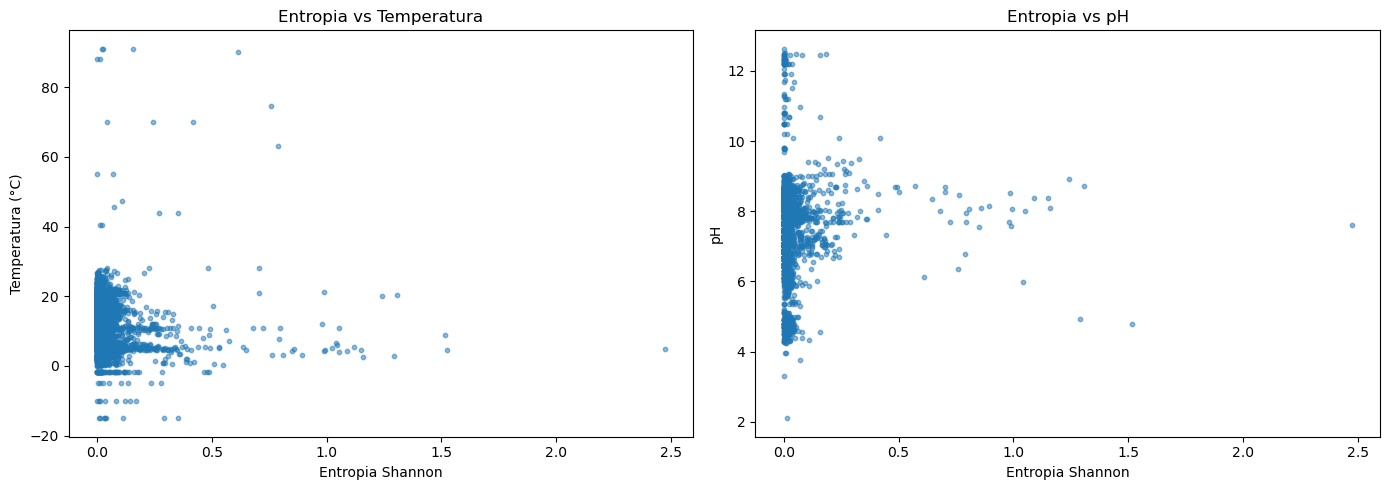

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_temp = pd.DataFrame({
    'entropia': Hs,
    'temperatura': meta_aligned['temperature_deg_c']
}).dropna()

axes[0].scatter(df_temp['entropia'], df_temp['temperatura'], alpha=0.5, s=10)
axes[0].set_xlabel('Entropia Shannon')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Entropia vs Temperatura')

df_ph = pd.DataFrame({
    'entropia': Hs,
    'ph': meta_aligned['ph']
}).dropna()

axes[1].scatter(df_ph['entropia'], df_ph['ph'], alpha=0.5, s=10)
axes[1].set_xlabel('Entropia Shannon')
axes[1].set_ylabel('pH')
axes[1].set_title('Entropia vs pH')

plt.tight_layout()
#plt.savefig('entropia_temp_ph.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
gruppi = {}
for gruppo in meta_aligned['empo_2'].unique():
    mask = meta_aligned['empo_2'] == gruppo
    gruppi[gruppo] = XSB_150bp[mask]
    print(f"{gruppo}: {gruppi[gruppo].shape}")
gruppi.pop("Negative")
#gruppi.pop("Positive")

Plant: (1818, 81)
Non-saline: (8625, 81)
Animal: (6085, 81)
Saline: (953, 81)
Negative: (2, 81)


,p__Proteobacteria,p__Cyanobacteria,p__Bacteroidetes,p__TM6,p__Firmicutes,p__Chloroflexi,p__Unknown,p__Armatimonadetes,p__Gemmatimonadetes,p__OP3,...,p__OP1,p__TPD-58,p__AncK6,p__H-178,p__Caldiserica,p__OC31,p__Aquificae,p__OctSpA1-106,p__VHS-B3-43,p__Thermotogae
1883.empty.well.2.Crump.Artic.LTREB.main.lane4.NoIndex,3.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1883.vacant.Crump.Artic.LTREB.main.lane1.NoIndex,159.0,0.0,36.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Studio un solo gruppo

In [7]:
Hp, Hs = btc.entropy(gruppi['Plant'])
print('Entropia phyla')
print(Hp)
print('Entropia sample')
print(Hs)

Entropia phyla
p__Proteobacteria    484.369512
p__Cyanobacteria     269.545297
p__Bacteroidetes     374.043467
p__TM6                 3.664006
p__Firmicutes         19.206519
                        ...    
p__OC31                0.000110
p__Aquificae          -0.000000
p__OctSpA1-106        -0.000000
p__VHS-B3-43          -0.000000
p__Thermotogae        -0.000000
Length: 81, dtype: float64
Entropia sample
2229.S2.N22.EH1.Thomas.CMB.Seaweed.lane6.NoIndex.L006              0.072914
2229.W1.N2.4.HP4.Thomas.CMB.Seaweed.lane5.NoIndex.L005             0.009078
2229.W2.N3.4.SE5.Thomas.CMB.Seaweed.lane6.NoIndex.L006             0.065742
2382.RU006.C181.RH.2.383.root.9.11.lane1.NoIndex.L001.sequences    0.352922
2229.S2.T21.PS2.Thomas.CMB.Seaweed.lane6.NoIndex.L006              0.025273
                                                                     ...   
1024.SH004.C1.RH.1.2.rhizo.6.11.G1.L00                             0.013611
2382.SH004.C1.RH.2.407.rhizo.4.12.lane7.NoIndex.L007.seque

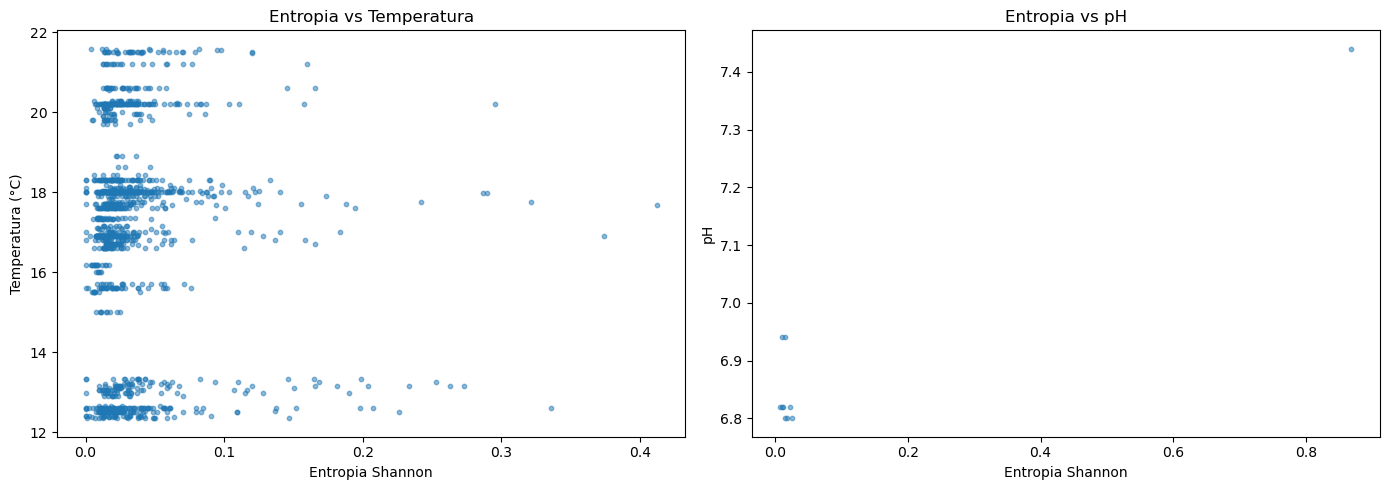

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_temp = pd.DataFrame({
    'entropia': Hs,
    'temperatura': meta_aligned['temperature_deg_c']
}).dropna()

axes[0].scatter(df_temp['entropia'], df_temp['temperatura'], alpha=0.5, s=10)
axes[0].set_xlabel('Entropia Shannon')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Entropia vs Temperatura')

df_ph = pd.DataFrame({
    'entropia': Hs,
    'ph': meta_aligned['ph']
}).dropna()

axes[1].scatter(df_ph['entropia'], df_ph['ph'], alpha=0.5, s=10)
axes[1].set_xlabel('Entropia Shannon')
axes[1].set_ylabel('pH')
axes[1].set_title('Entropia vs pH')

plt.tight_layout()
#plt.savefig('entropia_temp_ph.png', dpi=150, bbox_inches='tight')
plt.show()

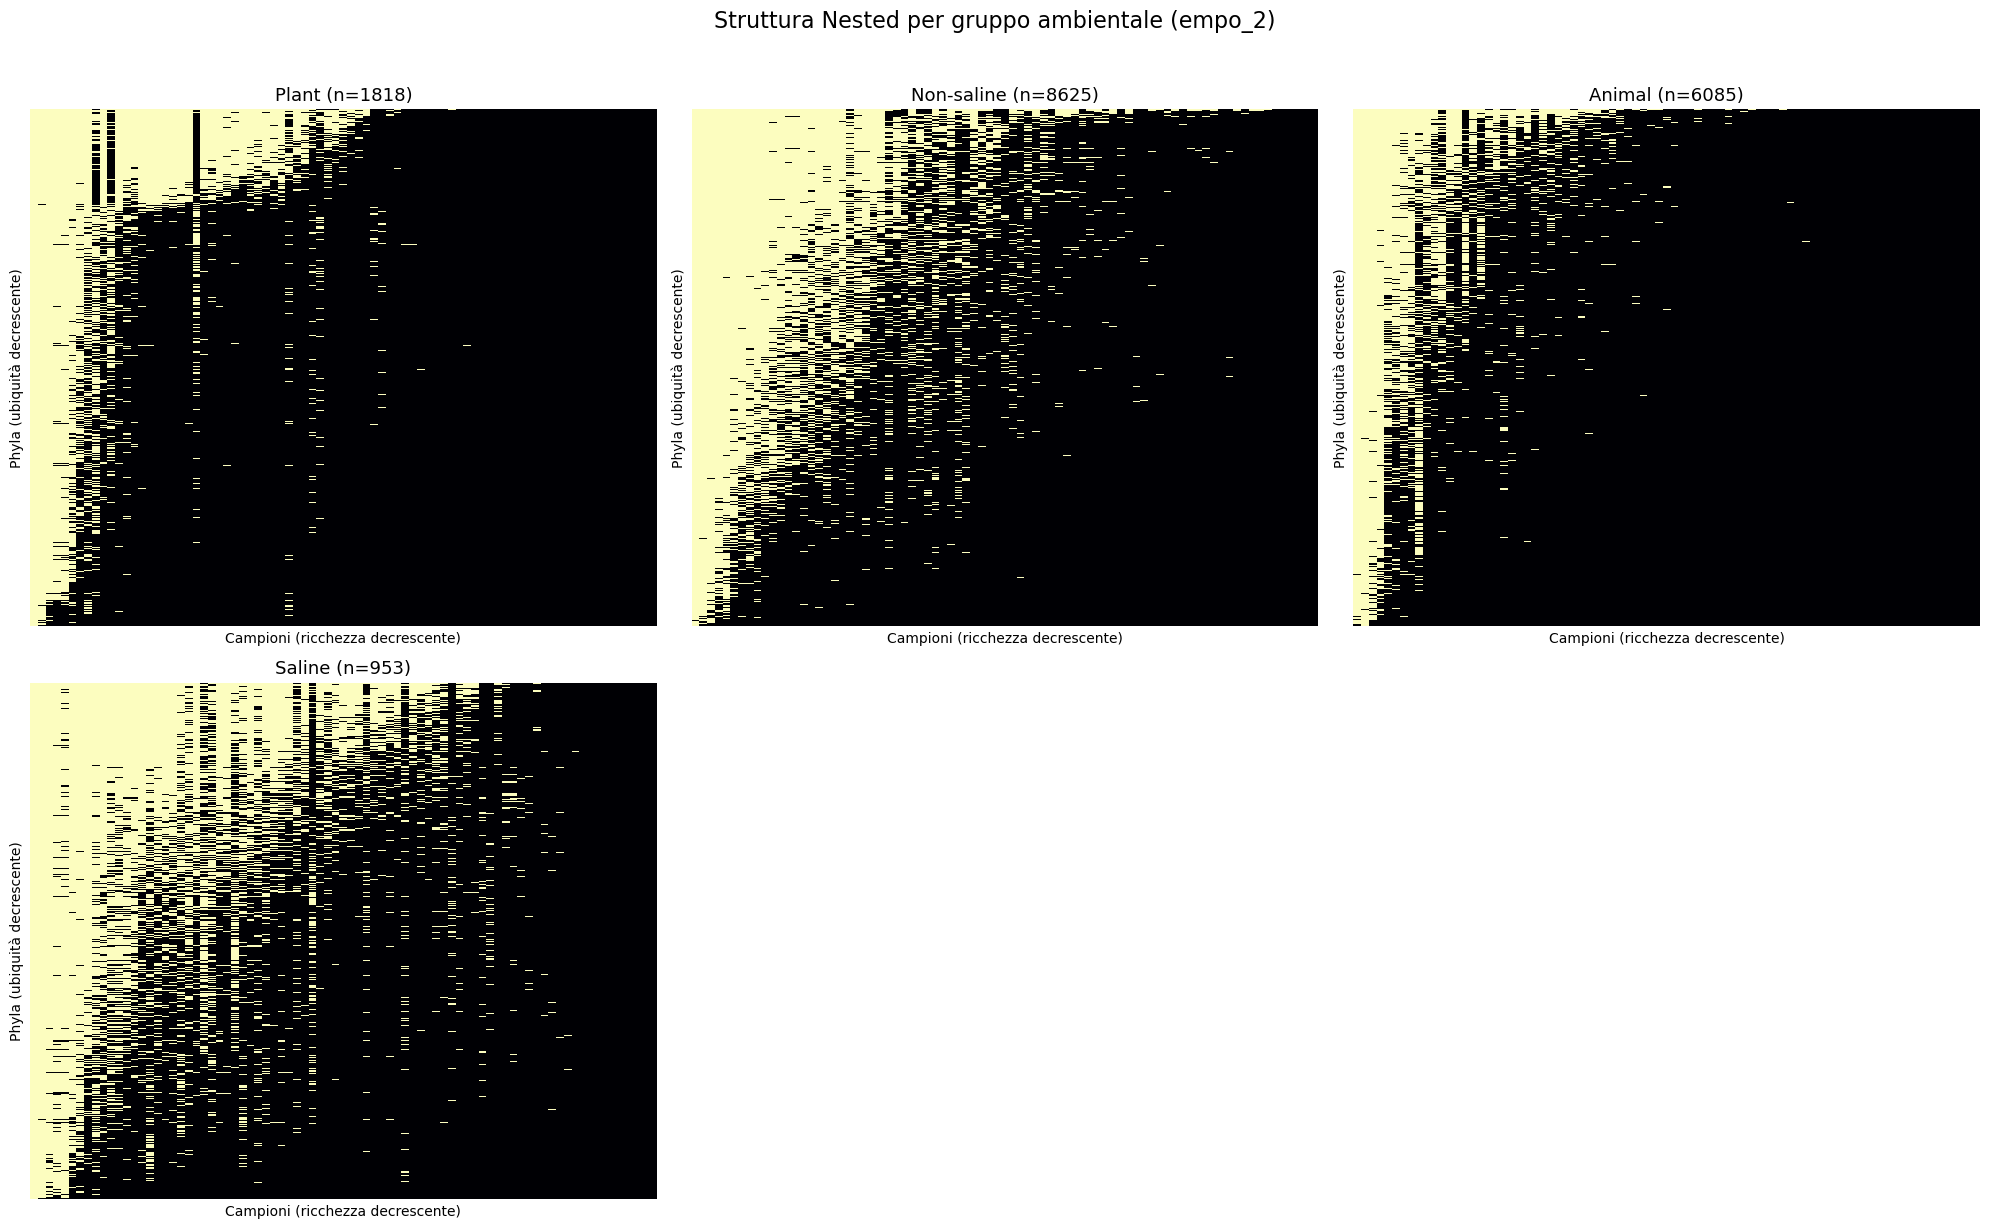

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, (gruppo, df) in enumerate(gruppi.items()):

    df_bin = (df > 0).astype(int)
    
    phyla_sum = df_bin.sum(axis=1)
    samples_sum = df_bin.sum(axis=0)
    
    df_sorted = df_bin.loc[
        phyla_sum.sort_values(ascending=False).index,
        samples_sum.sort_values(ascending=False).index
    ]
    
    sns.heatmap(df_sorted,
                cmap='magma',
                cbar=False,
                xticklabels=False,
                yticklabels=False,
                ax=axes[idx])
    
    axes[idx].set_title(f'{gruppo} (n={df.shape[0]})', fontsize=13)
    axes[idx].set_xlabel('Campioni (ricchezza decrescente)')
    axes[idx].set_ylabel('Phyla (ubiquità decrescente)')

for idx in range(len(gruppi), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Struttura Nested per gruppo ambientale (empo_2)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()